In [1]:
import sys, os
chemin_racine = os.path.abspath('..')
sys.path.insert(0, chemin_racine)
os.chdir(chemin_racine)

# 2. Le "Gold Standard" : Random Walk Metropolis-Hastings

Dans ce notebook, nous calculons la distribution a posteriori exacte de notre modèle MA(2) en utilisant l'algorithme Random Walk Metropolis-Hastings (RWMH). 

Puisque la vraisemblance du modèle MA(2) est calculable de manière exacte (elle est gaussienne), nous pouvons utiliser une méthode MCMC standard. Le résultat de cet algorithme nous servira de **"Gold Standard"** (vérité terrain) pour évaluer l'erreur inférentielle de nos futurs algorithmes ABC (qui utilisent des approximations).

**Objectifs :**
1. Calibrer l'algorithme pour obtenir un taux d'acceptation optimal (25% - 35%).
2. Vérifier la convergence de la chaîne (Trace plots).
3. Obtenir les vraies distributions marginales pour $\theta_1$ et $\theta_2$.

In [2]:
# --- COMMANDES MAGIQUES ---
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ma_model
from samplers.rwmh import run as run_rwmh, effective_sample_size

# Configuration visuelle
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(19)

## 1. Génération des données observées

Nous allons simuler une vraie série temporelle $y_{obs}$ avec des paramètres connus. C'est sur cette série que tous nos algorithmes (MCMC et ABC) vont travailler.

Simulation des données avec les vrais paramètres : theta_1 = 0.6, theta_2 = 0.2


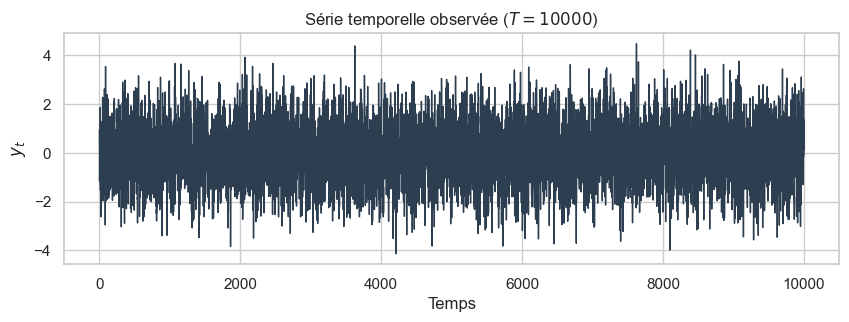

In [3]:
# Vrais paramètres
theta_true = np.array([0.6, 0.2])
T = 10000   # augmente de 200 a 500 pour concentrer la posteriore

print(f"Simulation des données avec les vrais paramètres : theta_1 = {theta_true[0]}, theta_2 = {theta_true[1]}")
y_obs = ma_model.simulate(theta_true, T, rng)

plt.figure(figsize=(10, 3))
plt.plot(y_obs, color='#2c3e50', lw=1)
plt.title(f"Série temporelle observée ($T={T}$)")
plt.xlabel("Temps")
plt.ylabel("$y_t$")
plt.savefig("figure.png")
plt.show()

## 2. Exécution du RWMH et Calibration

Nous lançons la chaîne de Markov. L'enjeu principal ici est de régler le paramètre `proposal_scale`.
* S'il est trop grand, la chaîne propose des sauts trop éloignés qui sont toujours rejetés (taux d'acceptation trop bas, la chaîne reste bloquée).
* S'il est trop petit, la chaîne accepte tout mais avance comme un escargot (mauvaise exploration).

*Note : La fonction de l'algorithme s'occupe elle-même de retirer le burn-in (période de chauffe).*

In [4]:
# --- PARAMÈTRES MCMC ---
n_iter = 1000_000         # Longueur totale de la chaîne (budget de calcul)
burnin = 5_000          # Nombre d'itérations jetées au début
proposal_scale = 0.01   # reduit car la posteriore est plus concentree avec T=500

print("Lancement du Gold Standard (RWMH)...")
result_gold = run_rwmh(
    y_obs=y_obs,
    n_iter=n_iter,
    proposal_scale=proposal_scale,
    burnin=burnin,
    rng=rng,
    show_progress=True
)

# Résumé des résultats
print("\n--- Résumé ---")
result_gold.summary()

Lancement du Gold Standard (RWMH)...


RWMH:   0%|                                                                                                                    | 0/1000000 [00:00<?, ?it/s]

RWMH:   0%|▏                                                                                                     | 1864/1000000 [00:00<00:53, 18635.71it/s]

RWMH:   0%|▍                                                                                                     | 3728/1000000 [00:00<00:53, 18483.12it/s]

RWMH:   0%|▎                                                                                       | 3728/1000000 [00:00<00:53, 18483.12it/s, accept=49.9%]

...

RWMH: 100%|█████████████████████████████████████████████████████████████████████████████████████▊| 997941/1000000 [00:53<00:00, 18713.15it/s, accept=50.1%]

RWMH: 100%|█████████████████████████████████████████████████████████████████████████████████████▉| 999836/1000000 [00:53<00:00, 18780.24it/s, accept=50.1%]

RWMH: 100%|█████████████████████████████████████████████████████████████████████████████████████▉| 999836/1000000 [00:53<00:00, 18780.24it/s, accept=50.1%]

RWMH: 100%|█████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:53<00:00, 18601.61it/s, accept=50.1%]


--- Résumé ---
  Échantillons   : 995000
  Temps CPU      : 53.72s
  Appels modèle  : 1000000
  Moyenne        : theta_1=0.6078, theta_2=0.2041
  Écart-type     : theta_1=0.0098, theta_2=0.0099
  IC 95% theta_1 : [0.5884, 0.6270]
  IC 95% theta_2 : [0.1846, 0.2233]
  accept_rate     : 0.501046
  burnin          : 5000
  proposal_scale  : 0.01


## 3. Diagnostics : ESS (Effective Sample Size)

L'ESS est une métrique cruciale. Comme les échantillons d'une chaîne MCMC sont corrélés (chaque point dépend du précédent), 50 000 échantillons MCMC ne valent pas 50 000 échantillons indépendants. 
L'ESS nous dit combien d'échantillons *réellement indépendants* nous avons obtenus.

In [5]:
# Utilisation de la superbe fonction écrite dans le code du binôme
ess = effective_sample_size(result_gold.samples)

print("Taille effective de l'échantillon (ESS) :")
print(f"  theta_1 : {ess[0]:.0f} échantillons indépendants équivalents")
print(f"  theta_2 : {ess[1]:.0f} échantillons indépendants équivalents")

print(f"\nEfficacité (ESS / seconde) :")
print(f"  theta_1 : {ess[0] / result_gold.cpu_time:.1f} iter/s")
print(f"  theta_2 : {ess[1] / result_gold.cpu_time:.1f} iter/s")

Taille effective de l'échantillon (ESS) :
  theta_1 : 76128 échantillons indépendants équivalents
  theta_2 : 75954 échantillons indépendants équivalents

Efficacité (ESS / seconde) :
  theta_1 : 1417.2 iter/s
  theta_2 : 1414.0 iter/s


## 4. Analyse Visuelle (Trace et Marginales)

Vérifions que notre chaîne a bien la forme d'une "chenille velue" (hairy caterpillar) et observons où la vraie distribution a posteriori est concentrée.

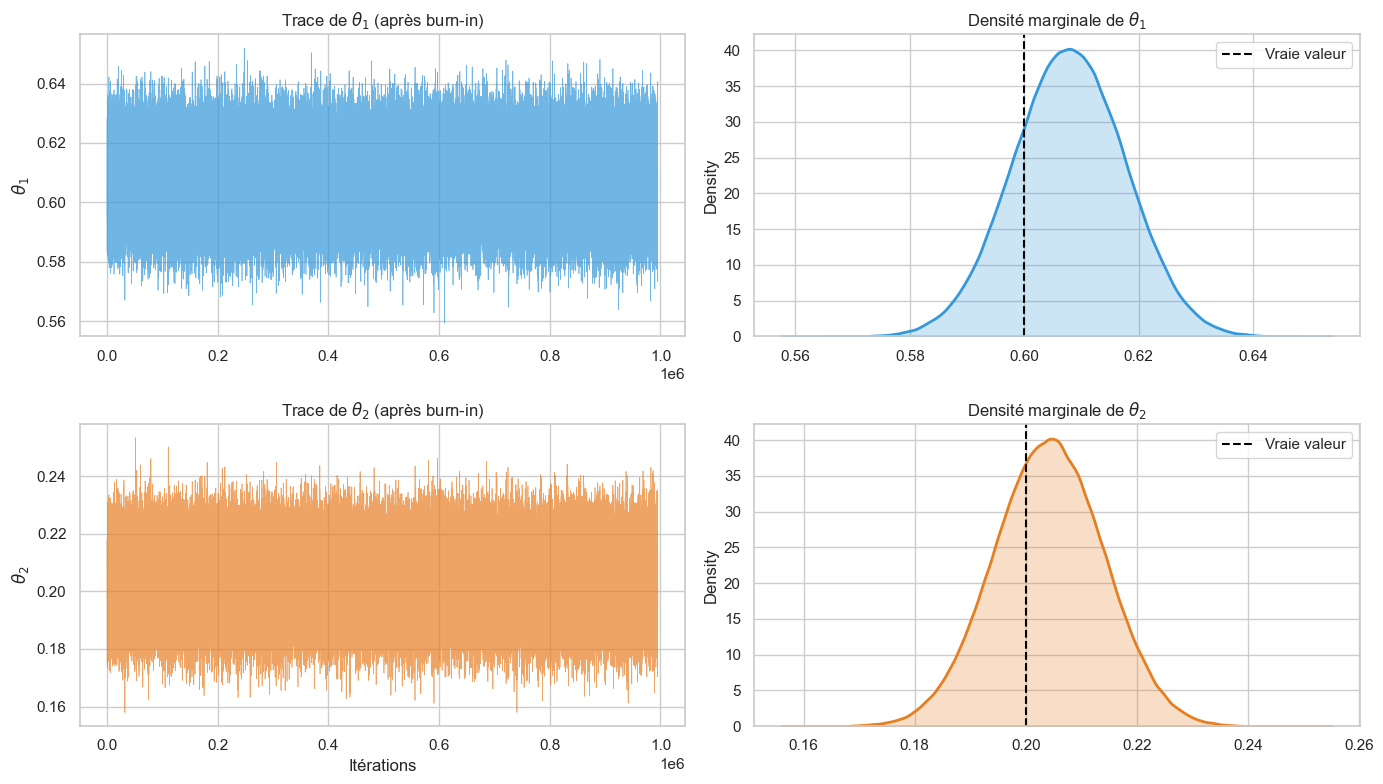

In [6]:
samples = result_gold.samples

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. TRACE PLOTS (Évolution dans le temps)
axes[0, 0].plot(samples[:, 0], color='#3498db', alpha=0.7, lw=0.5)
axes[0, 0].set_title(r"Trace de $\theta_1$ (après burn-in)")
axes[0, 0].set_ylabel(r"$\theta_1$")

axes[1, 0].plot(samples[:, 1], color='#e67e22', alpha=0.7, lw=0.5)
axes[1, 0].set_title(r"Trace de $\theta_2$ (après burn-in)")
axes[1, 0].set_ylabel(r"$\theta_2$")
axes[1, 0].set_xlabel("Itérations")

# 2. DENSITÉS MARGINALES (La vraie distribution a posteriori)
sns.kdeplot(samples[:, 0], ax=axes[0, 1], color='#3498db', fill=True, lw=2)
axes[0, 1].axvline(theta_true[0], color='black', linestyle='--', label='Vraie valeur')
axes[0, 1].set_title(r"Densité marginale de $\theta_1$")
axes[0, 1].legend()

sns.kdeplot(samples[:, 1], ax=axes[1, 1], color='#e67e22', fill=True, lw=2)
axes[1, 1].axvline(theta_true[1], color='black', linestyle='--', label='Vraie valeur')
axes[1, 1].set_title(r"Densité marginale de $\theta_2$")
axes[1, 1].legend()

plt.tight_layout()
plt.show()